## Data Processing

### Setup

In [1]:
import os
import multiprocessing
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms

import nibabel as nib
import albumentations as alb

/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.5' (you have '2.0.4'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


### Data Paths

In [3]:
def create_dataset_path_df(dataset_dir):
    flair_suffix = "flair.nii.gz"
    t1_suffix = "t1.nii.gz"
    t1ce_suffix = "t1ce.nii.gz"
    t2_suffix = "t2.nii.gz"
    seg_suffix = "seg.nii.gz"
    dataset_dict = {
                    'directory_path':[],
                    'flair_path':[],
                    't1_path':[],
                    't1ce_path':[],
                    't2_path':[],
                    'seg_path':[]
                    }
    missing_flair = 0
    missing_t1 = 0
    missing_t1ce = 0
    missing_t2 = 0
    missing_seg = 0
    missing_files_dirs = []
    for dir in os.listdir(dataset_dir):
        dir_path = os.path.join(dataset_dir,dir)
        if not os.path.isdir(dir_path) or not dir.startswith('BraTS2021'):
            continue
        dataset_dict['directory_path'].append(dir_path)
        
        flair_found = t1_found = t1ce_found = t2_found = seg_found = False
        for image in os.listdir(dir_path):
            image_path = os.path.join(dir_path, image)

            if image.endswith(flair_suffix):
                dataset_dict['flair_path'].append(image_path)
                flair_found = True
            elif image.endswith(t1_suffix):
                dataset_dict['t1_path'].append(image_path)
                t1_found = True
            elif image.endswith(t1ce_suffix):
                dataset_dict['t1ce_path'].append(image_path)
                t1ce_found = True
            elif image.endswith(t2_suffix):
                dataset_dict['t2_path'].append(image_path)
                t2_found = True
            elif image.endswith(seg_suffix):
                dataset_dict['seg_path'].append(image_path)
                seg_found = True

        if not flair_found:
            dataset_dict['flair_path'].append(None)
            missing_flair += 1
        if not t1_found:
            dataset_dict['t1_path'].append(None)
            missing_t1 += 1
        if not t1ce_found:
            dataset_dict['t1ce_path'].append(None)
            missing_t1ce += 1
        if not t2_found:
            dataset_dict['t2_path'].append(None)
            missing_t2 += 1
        if not seg_found:
            dataset_dict['seg_path'].append(None)
            missing_seg += 1
        if flair_found or t1_found or t1ce_found or t2_found or seg_found:
            pass
        else:
            missing_files_dirs.append(dir_path)
    print(f"Total missing files:")
    print(f"  - Flair: {missing_flair}")
    print(f"  - T1: {missing_t1}")
    print(f"  - T1ce: {missing_t1ce}")
    print(f"  - T2: {missing_t2}")
    print(f"  - Seg: {missing_seg}")
    print(f"Missing files at: {missing_files_dirs}")
    return pd.DataFrame(dataset_dict)

    return dataset_dict
dataset_dir = "../data/brats2021"
dataset = create_dataset_path_df(dataset_dir)
dataset.head()

Total missing files:
  - Flair: 0
  - T1: 0
  - T1ce: 0
  - T2: 0
  - Seg: 0
Missing files at: []


,directory_path,flair_path,t1_path,t1ce_path,t2_path,seg_path
0,../data/brats2021/BraTS2021_00000,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...,../data/brats2021/BraTS2021_00000/BraTS2021_00...
1,../data/brats2021/BraTS2021_00002,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...,../data/brats2021/BraTS2021_00002/BraTS2021_00...
2,../data/brats2021/BraTS2021_00003,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...,../data/brats2021/BraTS2021_00003/BraTS2021_00...
3,../data/brats2021/BraTS2021_00005,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...,../data/brats2021/BraTS2021_00005/BraTS2021_00...
4,../data/brats2021/BraTS2021_00006,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...,../data/brats2021/BraTS2021_00006/BraTS2021_00...


In [4]:
train_size = 0.8
val_size = 0.1
test_size = 0.1
random_state = 42
dataset_train, temp = train_test_split(dataset, test_size = val_size+test_size, random_state = random_state)
dataset_val, dataset_test = train_test_split(temp, test_size = test_size / (val_size + test_size), random_state = random_state)
print(f"Train set shape: {dataset_train.shape}")
print(f"Validation set shape: {dataset_val.shape}")
print(f"Test set shape: {dataset_test.shape}")

Train set shape: (1000, 6)
Validation set shape: (125, 6)
Test set shape: (126, 6)


### Custom Dataset Class

In [5]:
class BrainTumorDataset(Dataset):
    def __init__(self, datapath_df, upper_bound=100, lower_bound=60, window_size = 3, new_height=None, new_width=None,transformations=None):
        self._datapath_df = datapath_df
        self.upper_bound = upper_bound
        self.lower_bound = lower_bound
        self.window_size = window_size
        self.transformations = transformations

    def __len__(self):
        return self._datapath_df.shape[0]

    def _normalize_data(self, volume):
        mean = np.mean(volume)
        if mean==0:
            mean = 1
        std = np.std(volume)
        return (volume-mean)/std

    def _get_adjacent_slices(self, data, mask):
        # Return data: [Modalities x window_size x Height x Width] * (Depth-window_size+1),
        # Return mask: [Height x Width] * (Depth-window_size+1)
        slices = []
        masks = []
        
        depth = data.shape[-1]
        start = max(self.lower_bound, 0)
        end = min(self.upper_bound, depth)
        
        for i in range(start, end - self.window_size + 1):
            # If window size is 1, directly take the slice without concatenation
            if self.window_size == 1:
                slice_group = data[:, :, :, i].transpose(1, 2, 0).astype(np.float32)
            else:
                slice_group = np.concatenate(
                    [data[:, :, :, j].transpose(1, 2, 0).astype(np.float32) for j in range(i, i + self.window_size)], 
                    axis=-1
                )
            slices.append(slice_group)
            masks.append(mask[:, :, i + self.window_size // 2].astype(np.uint8))
        
        return slices, masks

    def __getitem__(self, index):
        data = []
        row = self._datapath_df.iloc[index]
        data.append(self._normalize_data(nib.load(row.flair_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t1ce_path).get_fdata()))
        data.append(self._normalize_data(nib.load(row.t2_path).get_fdata()))
        data = np.stack(data, axis=0)
        height = data.shape[1] if not new_height else new_height
        width = data.shape[2] if not new_width else new_width
        num_modalities = data.shape[0]
        num_slices = self.window_size


        mask = nib.load(row.seg_path).get_fdata()
        mask[mask == 4] = 3
        data, mask = self._get_adjacent_slices(data, mask)
        if self.transformations:
            spatial_transforms = self.transformations.get('spatial_transforms',None)
            intensity_transforms = self.transformations.get('intensity_transforms',None)

            if spatial_transforms:
                for i in range(len(data)):
                    augmented_data = spatial_transforms(image=data[i], mask=mask[i])
                    data[i], mask[i] = augmented_data["image"], augmented_data["mask"]
            if intensity_transforms:
                for i in range(len(data)):
                    augmented_data = intensity_transforms(image=data[i])
                    data[i] = augmented_data["image"]

        for i in range(len(data)):
            data[i] = data[i].reshape((height, width, num_slices, num_modalities))
            data[i] = data[i].transpose(3, 2, 0, 1)
        return data, mask

### Transforms

| **Augmentation**    | **Function**                                                                                             | **Reasoning**                                                                                                                                       |
|-------------------------------|-------------------------------------------------------------------------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Horizontal Flip               | Randomly flips the image horizontally.                                                                                 | Increases training data diversity; however, caution is needed because brain hemispheres can be lateralized, and tumors may show a side-specific distribution.    |
| Rotation                      | Rotates the image by a small angle (±5°).                                                                               | Mimics slight head tilts during MRI acquisition, helping the model learn minor orientation variations without distorting anatomical structures.                  |
| Random Scale                  | Scales the image by a factor within ±8%.                                                                               | Simulates variations in scanner zoom or patient size while preserving the relative sizes of brain structures and tumor-to-brain ratios.                             |
| Elastic Transform             | Applies smooth, local deformations to the image.                                                                       | Mimics realistic soft-tissue deformations in MR images; careful parameter tuning prevents unrealistic warping of critical tumor morphology.                       |
| Affine Transform              | Performs minor translations, rotations, and scaling simultaneously.                                                  | Adjusts for slight differences in patient positioning; maintains anatomical consistency while introducing subtle spatial variability.                           |
| Pad & Resize                  | Pads the image (if necessary) and resizes it to a fixed dimension (e.g., 240×240).                                      | Ensures uniform input dimensions for the network, which is vital for consistent performance and accurate segmentation.                                             |
| Random Brightness/Contrast    | Adjusts brightness and contrast within a moderate range (±15%).                                                        | Reflects variations in imaging conditions and scanner calibration while preserving subtle tumor intensity differences critical for segmentation.                |
| GaussNoise                    | Adds Gaussian noise with moderate variance.                                                                          | Emulates scanner noise found in real MR images, which helps the model become robust to noise without masking important details of tumor boundaries.             |
| Random Gamma Correction       | Modifies the image gamma within a narrow range (98–102).                                                               | Maintains clinically relevant intensity distributions and preserves tumor contrast, ensuring that subtle intensity variations remain interpretable.              |
| Median Blur                   | Applies a slight blur to reduce noise while preserving edges.                                                        | Helps in reducing high-frequency noise and artifacts without losing the sharp boundaries needed for precise delineation of tumor margins.                         |


In [6]:
new_height = 240
new_width = 240
percentage_crop = 30
transformations = {}
val_transformations = {}
val_spatial_transforms = alb.Compose([
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})
spatial_transforms = alb.Compose([
    alb.HorizontalFlip(p=0.3),
    alb.Rotate(limit=5, p=0.3),
    alb.RandomScale(scale_limit=0.08, p=0.3),
    alb.ElasticTransform(alpha=1, sigma=2.5, p=0.2),
    alb.Affine(scale=(0.95, 1.05), translate_percent=(0.02, 0.02), rotate=(-5, 5), p=0.3, fit_output=False),
    alb.OneOf([
        alb.RandomCrop(height=new_height*(100-percentage_crop)//100, width=new_width*(100-percentage_crop)//100),
        alb.CenterCrop(height=new_height*(100-percentage_crop)//100, width=new_width*(100-percentage_crop)//100),\
    ],p=0.5),
    alb.PadIfNeeded(min_height=new_height, min_width=new_width),
    alb.Resize(new_height, new_width)
], additional_targets={"mask":"mask"})
intensity_transforms = alb.Compose([
    alb.RandomBrightnessContrast(brightness_limit=0.05, contrast_limit=0.05, p=0.4), 
    alb.GaussNoise(p=0.3),
    alb.RandomGamma(gamma_limit=(95, 105), p=0.3), 
    alb.MedianBlur(blur_limit=(3,3), p=0.2), 
])

transformations['spatial_transforms'] = spatial_transforms
transformations['intensity_transforms'] = None
val_transformations['spatial_transforms'] = val_spatial_transforms

In [7]:
upper_bound=100
lower_bound=60
window_size = 1
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=transformations,
                             new_height = new_height,
                             new_width = new_width
                             )
data, mask = test_data[0]
print(f"Number of Datapoits: {len(data)}")
print(f"Data Shape: {data[0].shape}")
print(f"Mask Shape: {mask[0].shape}")

Number of Datapoits: 40
Data Shape: (4, 1, 240, 240)
Mask Shape: (240, 240)


Text(0.5, 1.0, 'Mask')

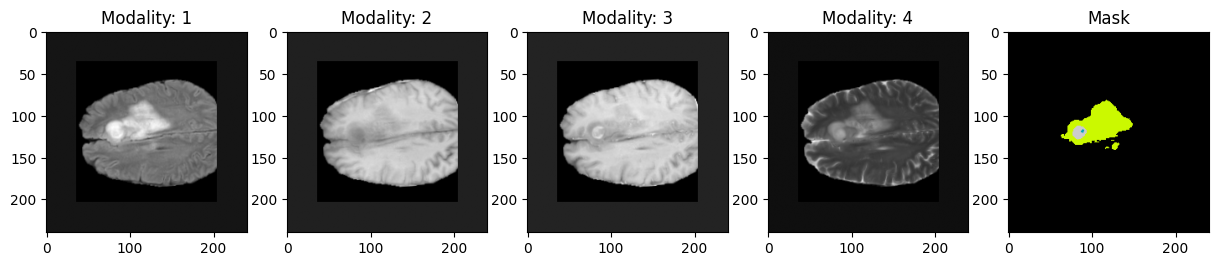

In [8]:
data_point_idx = np.random.randint(len(data)-1)
batch_idx = np.random.randint(upper_bound-lower_bound)
data, mask = test_data[data_point_idx]
anchor_slice = window_size//2

plt.figure(figsize=(15,15))

for i in range(data[batch_idx].shape[0]):
    plt.subplot(4,5,i+1)
    plt.imshow(data[batch_idx][i,anchor_slice, :,:], cmap="gray")
    plt.title(f"Modality: {i+1}")

plt.subplot(4,5,i+2)
plt.imshow(mask[batch_idx], cmap="nipy_spectral")
plt.title("Mask")

### Dataloader

In [9]:
upper_bound=100
lower_bound=60
window_size = 1
num_modalities = 4
train_data = BrainTumorDataset(dataset_train,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             transformations=transformations,
                             new_height = new_height,
                             new_width = new_width)
val_data = BrainTumorDataset(dataset_val,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             new_height = new_height,
                             new_width = new_width,
                             transformations=val_transformations)
test_data = BrainTumorDataset(dataset_test,
                             upper_bound=upper_bound, 
                             lower_bound=lower_bound, 
                             window_size = window_size, 
                             new_height = new_height,
                             new_width = new_width,
                             transformations=val_transformations)
pd.Series({
    'Training dataset size:': len(train_data),
    'Validation dataset size:': len(val_data),
    'Testing dataset size:': len(test_data)
}).to_frame().style.hide(axis='columns')

Training dataset size:,1000
Validation dataset size:,125
Testing dataset size:,126


In [10]:
def collate_fn(batch):
    data = []
    mask = []
    for X, label in batch:
        data.extend(X)
        mask.extend(label)
    data = np.array(data)
    mask = np.array(mask)
    data = torch.tensor(data, dtype=torch.float32)
    mask = torch.tensor(mask, dtype=torch.float32)
    return data, mask

per_datapoint_batch_size = (upper_bound-lower_bound)-window_size+1
batch_size_multiplication_factor = 2
batch_size = int(per_datapoint_batch_size*batch_size_multiplication_factor)
num_workers = multiprocessing.cpu_count()//2
# num_workders = -1
persistent_workers = True
pin_memory = True if device=='cuda' else False
pin_memory_device = device
data_loader_params = {
    'batch_size': batch_size_multiplication_factor,
    'num_workers': num_workers,
    'persistent_workers': persistent_workers,
    'pin_memory': pin_memory,
    'pin_memory_device': pin_memory_device,
    'collate_fn': collate_fn,
}
print(f'Number of datapoints per batch {batch_size}')
train_dataloader = DataLoader(train_data, **data_loader_params, shuffle=True)
val_dataloader = DataLoader(val_data, **data_loader_params)
test_dataloader = DataLoader(test_data, **data_loader_params)

Number of datapoints per batch 80


/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 14 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [11]:
pd.Series({
    'Number of batches in train dataLoader:': len(train_dataloader),
    'Number of batches in validation dataLoader:': len(val_dataloader),
    'Number of batches in test dataLoader:': len(test_dataloader)
}).to_frame().style.hide(axis='columns')

Number of batches in train dataLoader:,500
Number of batches in validation dataLoader:,63
Number of batches in test dataLoader:,63


In [12]:
for batch_idx, (data, mask) in enumerate(train_dataloader):
    print("Unique values in masks:", torch.unique(mask))
    
    print(f"Batch {batch_idx}:")
    print(f"  Data shape: {data.shape}")
    print(f"  Mask shape: {mask.shape}")
    break

Unique values in masks: tensor([0., 1., 2., 3.])
Batch 0:
  Data shape: torch.Size([80, 4, 1, 240, 240])
  Mask shape: torch.Size([80, 240, 240])


## Model Training

### Setup

In [13]:
import torch
import segmentation_models_pytorch as smp
from monai.networks.utils import one_hot
from monai.transforms import AsDiscrete
from monai.networks.nets import AttentionUnet as MAttentionUnet
from monai.networks.nets import UNETR, UNet
from monai.data import decollate_batch
from monai.losses import DiceLoss, DiceCELoss, HausdorffDTLoss
from monai.metrics import DiceMetric
from opacus.validators import ModuleValidator
from opacus import PrivacyEngine

In [14]:
seed = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

### Model

#### UNET Base

In [15]:
class UNETBase(torch.nn.Module):
    def __init__(self,):
        super(UNETBase, self).__init__()
        self.unet = UNet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 64, 128, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 1, 1, 1),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.3,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

#### UNETR

In [47]:
class UNETR_V0(torch.nn.Module):
    def __init__(self,):
        super(UNETR_V0, self).__init__()
        self.unetr = UNETR(
                            in_channels=4,       # Number of input channels (modalities) → T1, T2, FLAIR, T1ce
                            out_channels=4,      # Number of output segmentation classes (1 = binary, >1 = multi-class)
                            
                            img_size=(16, 240, 240),  # Input size → (Depth slices, Height, Width)
                            # patch_size=(1, 16, 16), # Visual token size
                            
                            feature_size=16,     # Base feature size of the encoder (affects transformer token dimensions)
                            hidden_size=768,     # Transformer hidden size (same as ViT/UNETR)
                            mlp_dim=3072,        # MLP feed-forward layer dimension (typically 4×hidden_size)
                            
                            num_heads=12,        # Number of self-attention heads in transformer blocks (higher = more expressive)
                            proj_type="perceptron",  # Type of projection (alternative is "conv" for convolutional projection)
                            
                            norm_name="instance", # Type of normalization → "instance" (better for medical images) or "batch"
                            res_block=True,      # Use residual connections in CNN decoder blocks (helps gradient flow)
                            
                            dropout_rate=0.1,    # Dropout applied in transformer layers (0.0 = no dropout, useful in small datasets)
                        )
    def forward(self, X):
        X = self.unetr(X)
        return X

In [ ]:
dummy_input = torch.randn((2, 4, 16, 240, 240))
unetr = UNETR_V0().to('cuda') # Number of parameters: 130.568M
num_params = sum(p.numel() for p in unetr.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))
dummy_output = unetr(dummy_input.to('cuda'))
dummy_output.shape

Conclusion
- Model is too big for 12G GPU.
- UNETR can't process depth of 3. It has to be larger >=16

Resolution
- UNET for 2D segmention where modalities and depth are combined.
- Add attention to get optimal weightage.

#### UNET With Merged Modalities & Depth - Attention, No residuals.

In [14]:
class UNET_V0(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 1, 1),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.3,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [16]:
class UNET_V0_1(torch.nn.Module):
    def __init__(self,):
        super(UNET_V0_1, self).__init__()
        self.positional_embedding = torch.nn.Parameter(torch.randn(int(num_modalities*window_size), new_height, new_width))
        self.unet = MAttentionUnet(
                        spatial_dims=2,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=int(num_modalities*window_size),       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(2, 2, 2, 2),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.4,          # Dropout rate for regularization (optional)
                    )
    
    def forward(self, X):
        X = X + self.positional_embedding.unsqueeze(0)
        X = self.unet(X)
        return X

In [ ]:
# dummy_input = torch.randn((2, 12, 240, 240))
# unet = UNET_V0().to('cuda') # V0 - Number of parameters: 495.608K, V0.1 Number of parameters: 11.86M
# dummy_output = unet(dummy_input.to('cuda'))
# dummy_output.shape

#### UNET With Merged Modalities & Depth - Pretrained Weight + Residuals + Attention (Only 2D)

In [ ]:
class UNET_V1(torch.nn.Module):
    def __init__(self,):
        super(UNET_V1, self).__init__()
        self.unet = smp.Unet(
                    encoder_name="resnet34",        # Encoder: resnet34/ efficientnet-b0 / resnet50
                    encoder_weights=None,     # Pre-trained on ImageNet
                    in_channels=int(num_modalities*window_size),                  # Number of input channels (e.g., RGB images)
                    classes=4,                      # Number of segmentation classes
                    activation="softmax2d",         # Multi-class segmentation requires softmax activation
                    decoder_attention_type="scse",  # Spatial and Channel Squeeze & Excitation (SCSE) attention
                )

    def forward(self, X):
        X = self.unet(X)
        return X

In [ ]:
dummy_input = torch.randn((2, 12, 256, 256))
unet = UNET_V1().to('cuda') # Number of parameters: 33.844 M
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape
num_params = sum(p.numel() for p in unet.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

#### UNET++ With Merged Modalities & Depth - Pretrained Weight + Residuals + Attention (Only 2D)

In [ ]:
class UNET_V2(torch.nn.Module):
    def __init__(self,):
        super(UNET_V2, self).__init__()
        self.unet = smp.UnetPlusPlus(
                    encoder_name="resnet50",        # Encoder: resnet34/ efficientnet-b0 / resnet50
                    encoder_weights="imagenet",     # Pre-trained on ImageNet
                    in_channels=12,                  # Number of input channels (e.g., RGB images)
                    classes=4,                      # Number of segmentation classes
                    activation="softmax2d",         # Multi-class segmentation requires softmax activation
                    decoder_attention_type="scse",  # Spatial and Channel Squeeze & Excitation (SCSE) attention
                )

    def forward(self, X):
        X = self.unet(X)
        return X

In [ ]:
dummy_input = torch.randn((2, 12, 256, 256))
unet = UNET_V2().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

#### UNET With Depth - Attention, No residuals.

In [ ]:
class UNET_V3(torch.nn.Module):
    def __init__(self,):
        super(UNET_V3, self).__init__()
        self.unet = MAttentionUnet(
                        spatial_dims=3,       # Specifies a 2D UNet (for slice-wise medical image segmentation)
                        in_channels=4,       # Number of input channels (e.g., multi-modal MRI with 12 input features)
                        out_channels=4,       # Number of output channels (multi-class segmentation with 4 classes)
                        channels=(16, 32, 64, 128),  # Number of feature maps at each level of the UNet
                        strides=(1, 1, 1, 2),  # Down-sampling factor at each level of the encoder (reduces spatial size)
                        kernel_size=3,        # Convolution kernel size
                        up_kernel_size=3,     # Kernel size for upsampling layers
                        dropout=0.1,          # Dropout rate for regularization (optional)
                    )

    def forward(self, X):
        X = self.unet(X)
        return X

In [ ]:
dummy_input = torch.randn((2, 4, 3, 240, 240))
unet = UNET_V3().to('cuda')
dummy_output = unet(dummy_input.to('cuda'))
dummy_output.shape

In [ ]:
# Discard 0 and 2, propogate loss for only 1
dummy_output[:,:,1,:,:] # torch.Size([2, 4, 240, 240])
torch.argmax(dummy_output[:,:,1,:,:], dim=1) # torch.Size([2, 240, 240])
print()

In [ ]:
dummy_input = torch.randn((2, 12, 240, 240))
dummy_input.reshape((2,3,4,240,240)).shape

### Hyperperameters

In [16]:
def define_optimizer_and_lr(model):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = T_max)
    # lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-4)
    # lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size, gamma)
    return optimizer, lr_scheduler

In [17]:
lr = 1e-3
weight_decay = 1e-3
step_size = 10
epochs = 100
T_max = epochs
gamma = 0.9

num_classes = 4
noise_multiplier = 1.2
max_grad_norm = 1.0

isDP = False
isDepth = False
isAdversarial = False
epsilon = 0.1



In [18]:
class DiceBoundaryLoss(torch.nn.Module):
    def __init__(self, alpha=0.7):
        super(DiceBoundaryLoss, self).__init__()
        self.alpha = alpha
        self.dice_loss = DiceCELoss(to_onehot_y=True, softmax=True)
        self.boundary_loss = HausdorffDTLoss(to_onehot_y=True, softmax=True)

    def forward(self, pred, target):
        dice = self.dice_loss(pred, target)
        boundary = self.boundary_loss(pred, target)
        total_loss = self.alpha * dice + (1 - self.alpha) * boundary
        return total_loss

In [19]:
model =  UNETBase().to(device)
loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)

In [20]:
num_params = sum(p.numel() for p in model.parameters())
print('Number of parameters: {:.3f}K'.format(num_params / 1000))

Number of parameters: 550.702K


### Differential Privacy

In [21]:
def differential_privacy(model, dataloader, noise_multiplier, max_grad_norm):
    model = ModuleValidator.fix(model)
    ModuleValidator.validate(model, strict=False)
    optimizer, lr_scheduler = define_optimizer_and_lr(model)
    privacy_engine = PrivacyEngine()
    model, optimizer, dataloader = privacy_engine.make_private(
        module = model,
        optimizer = optimizer,
        data_loader = dataloader,
        noise_multiplier=noise_multiplier,  # Higher = more privacy, but more noise
        max_grad_norm=max_grad_norm,  # Clipping to ensure DP
    )
    return model, optimizer, lr_scheduler, dataloader

In [22]:
# Instantiation
if isDP:
    model, optimizer, lr_scheduler, train_dataloader = differential_privacy(model, train_dataloader, noise_multiplier, max_grad_norm)
else:
    optimizer, lr_scheduler = define_optimizer_and_lr(model)

### Adversarial Noise Generation

In [23]:
def fgsm_attack(model, data, mask, epsilon):
    batch_size, modality, window, h, w = data.shape

    # Reshape to [Batch x (Modality * Window) x H x W]
    data = data.view(batch_size, modality * window, h, w)
    data.requires_grad = True

    # Forward pass
    output = model(data)
    loss = torch.nn.functional.cross_entropy(output, mask)

    # Backward pass
    model.zero_grad()
    loss.backward()

    # Generate adversarial example
    perturbation = epsilon * data.grad.sign()
    adv_data = data + perturbation
    adv_data = torch.clamp(adv_data, 0, 1)  # Keep pixel values in range [0, 1]

    # Reshape back to [Batch x Modality x Window x H x W]
    adv_data = adv_data.view(batch_size, modality, window, h, w)

    return adv_data

## Training Loop

### Imports

In [24]:
import os
import nibabel as nib
import numpy as np

import datetime
from pathlib import Path
import torch
import wandb
from torch.amp import autocast
import math
import json
from tqdm import tqdm

### WandB Login

In [67]:
wandb.login()

03/26/2025 17:51:07:ERROR:Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: hakeem-at (ReliableExplainableBrainTumorSegmentation) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Project Details and Model Checkpoint Path

In [68]:
project_name = f"BrainTumorSegmentation_V1"
dataset_name = 'BraTS2021'
class_names = ["BG", "NCR/NET", "ED", "ET"]

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
project_dir = Path(f"../checkpoints/{project_name}/")
checkpoint_dir = Path(project_dir/f"{timestamp}")
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir/f"{model.__class__.__name__}.pth"

print(checkpoint_path)

../checkpoints/BrainTumorSegmentation_V1/2025-03-26_17-51-07/UNETBase.pth


### Epoch Definition

In [69]:
def run_epoch(model, dataloader, optimizer, lr_scheduler, device, scaler, epoch_id, is_training, val_loss=None,use_adversarial=False, isDepth=False,epsilon=0.1):
    if is_training:
        model.train()
    else:
        model.eval()

    epoch_loss = 0
    epoch_dice = 0
    progress_bar = tqdm(total=len(dataloader), desc="Train" if is_training else "Eval", leave=False)
    
    for batch_id, (data, masks) in enumerate(dataloader):
        if not isDepth:
            data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with autocast(device_type=device.type, dtype=torch.float32):
            if is_training and use_adversarial:
                adv_data = fgsm_attack(model, data, masks, epsilon)
                data = torch.cat([data, adv_data], dim=0)
                masks = torch.cat([masks, masks], dim=0)
            if is_training:
                preds = model(data)
                loss = loss_function(preds, masks.unsqueeze(1))
                preds = torch.argmax(preds, dim=1)
                dice_metric(
                            y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                            )
                dice_score = dice_metric.aggregate().item()
                dice_metric.reset()
            else:
                with torch.no_grad():
                    preds = model(data)
                    loss = loss_function(preds, masks.unsqueeze(1))
                    preds = torch.argmax(preds, dim=1)
                    dice_metric(
                                y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                                y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                                )
                    dice_score = dice_metric.aggregate().item()
                    dice_metric.reset()
            log_prefix = 'training' if is_training else 'validation'
            wandb.log({f'{log_prefix}_epoch': epoch_id, 
                       f"{log_prefix}_batch_id": batch_id, 
                       f"{log_prefix}_loss": loss.item(), 
                       f"{log_prefix}_dice_score": dice_score})
        if is_training:
            if scaler:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                old_scaler = scaler.get_scale()
                scaler.update()
                new_scaler = scaler.get_scale()
                if new_scaler >= old_scaler:
                    lr_scheduler.step()
            else:
                loss.backward()
                optimizer.step()
                lr_scheduler.step()

            optimizer.zero_grad()

        loss_item = loss.item()
        epoch_loss += loss_item
        epoch_dice += dice_score

        progress_bar_dict = dict(loss=loss_item, avg_loss=epoch_loss/(batch_id+1))
        if is_training:
            progress_bar_dict.update(lr=lr_scheduler.get_last_lr()[0]) #lr=optimizer.param_groups[0]['lr']
        progress_bar.set_postfix(progress_bar_dict)
        progress_bar.update()

        if is_training:
            stop_training_message = f"Loss is NaN or infinite at epoch {epoch_id}, batch {batch_id}. Stopping training."
            assert not math.isnan(loss_item) and math.isfinite(loss_item), stop_training_message

    progress_bar.close()

    return epoch_loss / (batch_id + 1), epoch_dice / (batch_id + 1)

In [70]:
# def run_epoch(model, dataloader, optimizer, lr_scheduler, device, scaler, epoch_id, is_training, val_loss=None, use_adversarial=False, isDepth=False, epsilon=0.1, micro_batch_size=1):
#     if is_training:
#         model.train()
#     else:
#         model.eval()

#     epoch_loss = 0
#     epoch_dice = 0
#     progress_bar = tqdm(total=len(dataloader), desc="Train" if is_training else "Eval", leave=False)

#     for batch_id, (data, masks) in enumerate(dataloader):
#         if not isDepth:
#             data = data.reshape(data.shape[0], -1, data.shape[-2], data.shape[-1])
#         data = data.to(device)
#         masks = masks.to(device)
        
#         batch_loss = 0
#         batch_dice = 0
#         num_micro_batches = max(1, data.size(0) // micro_batch_size)

#         for i in range(num_micro_batches):
#             # Extract micro-batch
#             start_idx = i * micro_batch_size
#             end_idx = min(start_idx + micro_batch_size, data.size(0))
#             micro_data = data[start_idx:end_idx]
#             micro_masks = masks[start_idx:end_idx]

#             with autocast(device_type=device.type, dtype=torch.float32):
#                 if is_training and use_adversarial:
#                     adv_data = fgsm_attack(model, micro_data, micro_masks, epsilon)
#                     micro_data = torch.cat([micro_data, adv_data], dim=0)
#                     micro_masks = torch.cat([micro_masks, micro_masks], dim=0)

#                 if is_training:
#                     preds = model(micro_data)
#                     loss = loss_function(preds, micro_masks.unsqueeze(1)) / num_micro_batches  # Normalize loss
#                     preds = torch.argmax(preds, dim=1)
#                     dice_metric(
#                         y_pred=decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
#                         y=decollate_batch(one_hot(micro_masks.unsqueeze(1), num_classes=num_classes))
#                     )
#                     dice_score = dice_metric.aggregate().item()
#                     dice_metric.reset()
#                 else:
#                     with torch.no_grad():
#                         preds = model(micro_data)
#                         loss = loss_function(preds, micro_masks.unsqueeze(1)) / num_micro_batches  # Normalize loss
#                         preds = torch.argmax(preds, dim=1)
#                         dice_metric(
#                             y_pred=decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)),
#                             y=decollate_batch(one_hot(micro_masks.unsqueeze(1), num_classes=num_classes))
#                         )
#                         dice_score = dice_metric.aggregate().item()
#                         dice_metric.reset()

#                 # Accumulate loss and dice
#                 batch_loss += loss.item()
#                 batch_dice += dice_score

#                 # Backpropagation
#                 if is_training:
#                     if scaler:
#                         scaler.scale(loss).backward()
#                     else:
#                         loss.backward()

#         # Step optimizer and scheduler after accumulating over micro-batches
#         if is_training:
#             if scaler:
#                 scaler.step(optimizer)
#                 old_scaler = scaler.get_scale()
#                 scaler.update()
#                 new_scaler = scaler.get_scale()
#                 if new_scaler >= old_scaler:
#                     lr_scheduler.step()
#             else:
#                 optimizer.step()
#                 lr_scheduler.step()
#             optimizer.zero_grad()

#         # Log metrics
#         epoch_loss += batch_loss
#         epoch_dice += batch_dice

#         progress_bar_dict = dict(loss=batch_loss, avg_loss=epoch_loss / (batch_id + 1))
#         if is_training:
#             progress_bar_dict.update(lr=lr_scheduler.get_last_lr()[0])
#         progress_bar.set_postfix(progress_bar_dict)
#         progress_bar.update()

#         log_prefix = 'training' if is_training else 'validation'
#         wandb.log({f'{log_prefix}_epoch': epoch_id, 
#                    f"{log_prefix}_batch_id": batch_id, 
#                    f"{log_prefix}_loss": batch_loss, 
#                    f"{log_prefix}_dice_score": batch_dice / num_micro_batches})

#         if is_training:
#             stop_training_message = f"Loss is NaN or infinite at epoch {epoch_id}, batch {batch_id}. Stopping training."
#             assert not math.isnan(batch_loss) and math.isfinite(batch_loss), stop_training_message

#     progress_bar.close()
#     return epoch_loss / (batch_id + 1), epoch_dice / (batch_id + 1)


In [71]:
from IPython.display import clear_output

def train_loop(model,
               train_dataloader,
               valid_dataloader,
               optimizer,
               lr_scheduler,
               device,
               epochs,
               checkpoint_path,
               use_scaler=False,
               use_adv=False,
               isDepth = False,
               epsilon=0.1,
               patience=7):
    patience_count = 0
    scaler = torch.amp.GradScaler(device) if device == 'cuda' and use_scaler else None
    best_loss = float('inf')
    wandb.watch(model, log="all", log_freq=10)
    validation_loss = float('inf')
    patience_rest_threshold = 0.05
    for epoch in tqdm(range(epochs), desc="Epochs"):
        training_loss, training_dice = run_epoch(
            model, train_dataloader, optimizer, lr_scheduler, device, scaler, epoch,
            is_training=True, val_loss = validation_loss, use_adversarial=use_adv, epsilon=epsilon
        )
        clear_output()
        log_prefix = 'training'
        wandb.log({f'avg_{log_prefix}_epoch': epoch+1, 
                   f"avg_{log_prefix}_loss": training_loss, 
                   f"avg_{log_prefix}_dice_score": training_dice})
        with torch.no_grad():
            validation_loss, validation_dice = run_epoch(
                model, valid_dataloader, None, None, device, scaler, epoch,
                is_training=False
            )
        log_prefix = 'validation'
        wandb.log({f'avg_{log_prefix}_epoch': epoch+1, 
                   f"avg_{log_prefix}_loss": validation_loss, 
                   f"avg_{log_prefix}_dice_score": validation_dice})
        clear_output()
        if validation_loss < best_loss + (best_loss*patience_rest_threshold):
            best_loss = validation_loss
            patience_count=0
            torch.save(model.state_dict(), checkpoint_path)

            training_metadata = {
                'epoch': epoch,
                'train_loss': training_loss,
                'valid_loss': validation_loss,
                'learning_rate': lr_scheduler.get_last_lr()[0],
                'model_architecture': model.__class__.__name__
            }
            with open(checkpoint_path.with_name(checkpoint_path.stem + '_best_model.json'), 'w') as f:
                json.dump(training_metadata, f)
        else:
            patience_count+=1
        if patience_count>=patience:
            print('Early stopping triggered')
            torch.save(model.state_dict(), checkpoint_path)
            training_metadata = {
                'epoch': epoch,
                'train_loss': training_loss,
                'valid_loss': validation_loss,
                'learning_rate': lr_scheduler.get_last_lr()[0],
                'model_architecture': model.__class__.__name__
            }
            with open(checkpoint_path.with_name(checkpoint_path.stem + '_last_model.json'), 'w') as f:
                json.dump(training_metadata, f)
            break

    if device.type != 'cpu':
        getattr(torch, device.type).empty_cache()

### WandB Tracking

In [72]:
config = dict(
    epochs=epochs,
    learning_rate = lr,
    learning_rate_scheduler='CosineAnnealingLR',
    batch_size=batch_size,
    optimizer = 'AdamW',
    segmentation_loss = 'Dice + BCE',
    dice_loss_weight = 0.5,
    bce_loss_weight=0.5,
    adversarial_training=isAdversarial,
    epsilon=epsilon,
    classes=class_names,
    number_of_classes = len(class_names),
    dataset=f"{dataset_name}",
    train_data = len(dataset_train),
    validation_data = len(dataset_val),
    architecture=str(model),
    model_version = model.__class__.__name__,
    device = device,
    mixed_point_precision=True,
    automatic_mixed_precision=True)

wandb.init(
    project=project_name,
    config=config
)

### Training Loop Run

In [ ]:
train_loop(model=model,
           train_dataloader=train_dataloader,
           valid_dataloader=val_dataloader,
           optimizer=optimizer,
           lr_scheduler=lr_scheduler,
           device=torch.device(device),
           epochs=epochs,
           checkpoint_path=checkpoint_path,
           use_scaler=True,
           isDepth = isDepth)

in:  16%|█▌        | 81/500 [01:17<05:02,  1.39it/s, loss=0.572, avg_loss=0.516, lr=0.000914]

### Inference

In [32]:
model_path = '../checkpoints/BrainTumorSegmentation_V1/UNETBase/UNETBase.pth'
checkpoint = torch.load(model_path, map_location = device)
model = UNETBase().to(device)
model.load_state_dict(checkpoint)

<All keys matched successfully>

(-0.5, 239.5, 239.5, -0.5)

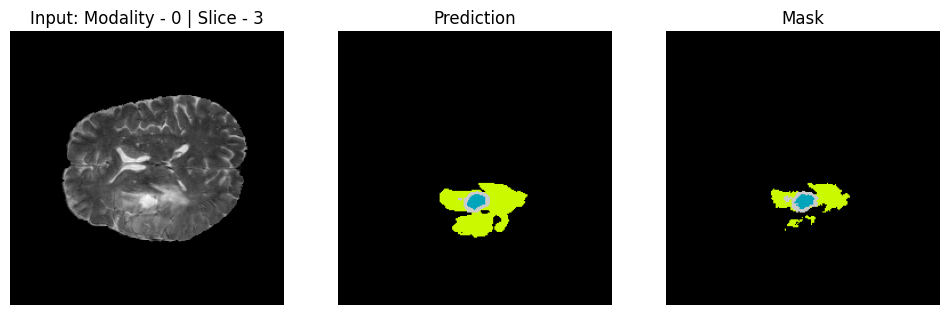

In [47]:
data, masks = next(iter(val_dataloader))
if not isDepth:
    data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
model.eval()
with torch.no_grad():
    logits = model(data.to(device))

probs = torch.softmax(logits, dim=1)
preds = torch.argmax(logits, dim=1)
idx = np.random.randint(preds.shape[0])

modality = 0 # 0-2, 3-5, 6-8, 9-11
slice_num = 3
scan = data[idx,slice_num,...].cpu().numpy()
pred = preds[idx].cpu().numpy()
mask = masks[idx].cpu().numpy()

plt.figure(figsize=(12,12))
plt.subplot(1,3,1)
plt.imshow(scan, cmap="grey")
plt.title(f"Input: Modality - {modality} | Slice - {slice_num}")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(pred, cmap="nipy_spectral")
plt.title("Prediction")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(mask, cmap="nipy_spectral")
plt.title("Mask")
plt.axis('off')

### Thresholding

In [88]:
model.eval()
for batch_id, (data, masks) in enumerate(val_dataloader):
    if not isDepth:
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        preds = model(data)
        preds = torch.argmax(preds, dim=1)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
dice_score = dice_metric.aggregate().item()
dice_metric.reset()
print(f'Base Score Without Threshold: {dice_score}')

Base Score Without Threshold: 0.7690841555595398


In [ ]:
thresholds = np.linspace(0,1, 20)
dice_scores = []
model.eval()
for threshold in thresholds:
    for batch_id, (data, masks) in enumerate(val_dataloader):
        if not isDepth:
            data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
        data = data.to(device)
        masks = masks.to(device)
        with torch.no_grad():
            preds = model(data)
            probs = torch.softmax(preds,dim=1)
            probs = torch.where(probs>=threshold,probs, torch.zeros_like(probs))
            preds = torch.argmax(probs, dim=1)
            dice_metric(
                        y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                        y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                        )
    dice_score = dice_metric.aggregate().item()
    dice_scores.append(dice_score)
    dice_metric.reset()
print(f'Common Optimal Threshold: {thresholds[np.argmax(dice_scores)]}\nDice Score: {max(dice_scores)}')

/home/hakeem.at/.conda/envs/BTSeg/lib/python3.12/site-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 14 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
thresholds = np.linspace(0,1, 20)
model.eval()
class_dice_scores = []
for class_i in range(1,num_classes):
    dice_scores = []
    for threshold in thresholds:
        for batch_id, (data, masks) in enumerate(val_dataloader):
            if not isDepth:
                data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
            data = data.to(device)
            masks = masks.to(device)
            with torch.no_grad():
                logits = model(data)
                probs = torch.softmax(logits,dim=1)
                class_probs = probs[:,class_i,:,:]
                class_probs = torch.where(class_probs>=threshold,class_probs, torch.zeros_like(class_probs))
                probs[:,class_i,:,:] = class_probs
                preds = torch.argmax(probs, dim=1)
                dice_metric(
                            y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                            y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                            )
        dice_score = dice_metric.aggregate().item()
        dice_scores.append(dice_score)
        dice_metric.reset()
    class_dice_scores.append(dice_scores)
class_thresholds = {}
for class_i in range(num_classes-1):
    class_dice_score = class_dice_scores[class_i]
    class_thresholds[class_i+1] = thresholds[np.argmax(class_dice_score)]
    print(f'Class-{class_i+1}\nOptimal Threshold: {class_thresholds[class_i]}\nDice Score: {max(class_dice_score)}\n{'-'*50}')

In [ ]:
model.eval()
for batch_id, (data, masks) in enumerate(val_dataloader):
    if not isDepth:
        data = data.reshape(data.shape[0],-1, data.shape[-2], data.shape[-1])
    data = data.to(device)
    masks = masks.to(device)
    with torch.no_grad():
        logits = model(data)
        probs = torch.softmax(logits,dim=1)
        for class_i in range(1,num_classes):
            class_probs = probs[:,class_i,:,:]
            class_probs = torch.where(class_probs>=class_thresholds[class_i], class_probs, torch.zeros_like(class_probs))
            probs[:,class_i,:,:] = class_probs
        preds = torch.argmax(probs, dim=1)
        dice_metric(
                    y_pred = decollate_batch(one_hot(preds.unsqueeze(1), num_classes=num_classes)), 
                    y = decollate_batch(one_hot(masks.unsqueeze(1), num_classes=num_classes))
                    )
dice_score = dice_metric.aggregate().item()
dice_metric.reset()
print(f'Final Score With Threshold Optimization: {dice_score}')